## Importing Necessary Packages and Gathering Data
This section deals with importing the packages that are used in this project, and loading in the data files (.csv) so they can be refrenced and manipulated in python. 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [5]:
# Oklahoma
ok_svi = pd.read_csv("Oklahoma.csv")

# Rhode Island
ri_svi = pd.read_csv("RhodeIsland.csv")

# NRI dictionary for reference
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

# Load in the NRI Census Tracts
tracts = pd.read_csv("NRI_Table_CensusTracts.csv")

# Load in the shape file
shape = gpd.read_file("NRI_Shapefile_CensusTracts.shp") 


## Sorting the Data by State

This block of code sorts the large dataset by individual states then exports them to a smaller, more managable .csv file.

In [6]:
#Rhode Island
ri_data = tracts[tracts["STATEABBRV"] == "RI"]
ri_data.to_csv("NRI_Table_CensusTracts_RhodeIsland.csv", index=False)

# Oklahoma
ok_data = tracts[tracts["STATEABBRV"] == "OK"]
ok_data.to_csv("NRI_Table_CensusTracts_Oklahoma.csv", index=False)

# Load in the newly created files
ri_nri = pd.read_csv('NRI_Table_CensusTracts_RhodeIsland.csv')
ok_nri = pd.read_csv('NRI_Table_CensusTracts_Oklahoma.csv')


## Merging the Datasets 
This section merges the NRI and SVI datasets so they can be referenced together. This is helpful becuase there is seperate information in both of the individual datasets that will need to be combined for the analysis. This is also requested by the client. Additionally, N/A values contained in the dataset are dropped since they can negatively affect the quality of the data. 

In [7]:
# Creating common columns in both datasets named "STCOFIPS" 
ok_svi['STCOFIPS'] = ok_nri['STCOFIPS']
ri_svi['STCOFIPS'] = ri_nri['STCOFIPS']

# Merging the data for Oklahoma
Oklahoma_data = pd.merge(ok_nri, ok_svi, on = 'STCOFIPS', suffixes=('', '_right'))

# Merging the data for Rhode Island
RhodeIsland_data = pd.merge(ri_nri, ri_svi, on = 'STCOFIPS', suffixes=('', '_right'))

# Dropping N/A values for both datasets
# This won't affect much since there seem to be no N/A values in the original datasets.

Oklahoma_data = Oklahoma_data.dropna(axis=1)
RhodeIsland_data = RhodeIsland_data.dropna(axis=1)


## Defining New Value for Risk
This section uses the newly defined definition of risk to calculate the risk of tornado in two different states. 

The two states selected are Oklahoma and Rhode Island

#### The new definition of risk: 

Risk = Risk Index = Probability * Impact

- TRND_AFREQ represents the probability variable (Annualized Tornado Frequency)
- TRND_EXPB represents the Impact (Exposure - Building Value)


In [8]:
# Creating a "tornado_building_risk" column in both complete datasets
Oklahoma_data['tornado_building_risk'] = Oklahoma_data['TRND_AFREQ'] * Oklahoma_data['TRND_EXPB']
RhodeIsland_data['tornado_building_risk'] = RhodeIsland_data['TRND_AFREQ']*RhodeIsland_data['TRND_EXPB']

# Creating a "tornado_building_risk" column in the shape file
shape['tornado_building_risk'] = shape['TRND_AFREQ']*shape['TRND_EXPB']


## Visualizations 
This section creates the necessary information and visualizations to analyze the new definition of risk to the original NRI definition.

In [9]:
# Run summary mean by county for each state - NEW DEFINITION

Oklahoma_mean_data_NEW = Oklahoma_data.groupby('COUNTY').agg(
    mean_tornado=('tornado_building_risk','mean'))

RhodeIsland_mean_data_NEW = RhodeIsland_data.groupby('COUNTY').agg(
    mean_tornado=('tornado_building_risk','mean'))

# Run summary mean by county for each state - NRI DEFINITION
Oklahoma_mean_data_NRI = Oklahoma_data.groupby('COUNTY').agg(
    mean_tornado=('TRND_RISKV','mean'))

RhodeIsland_mean_data_NRI = RhodeIsland_data.groupby('COUNTY').agg(
    mean_tornado=('TRND_RISKV','mean'))


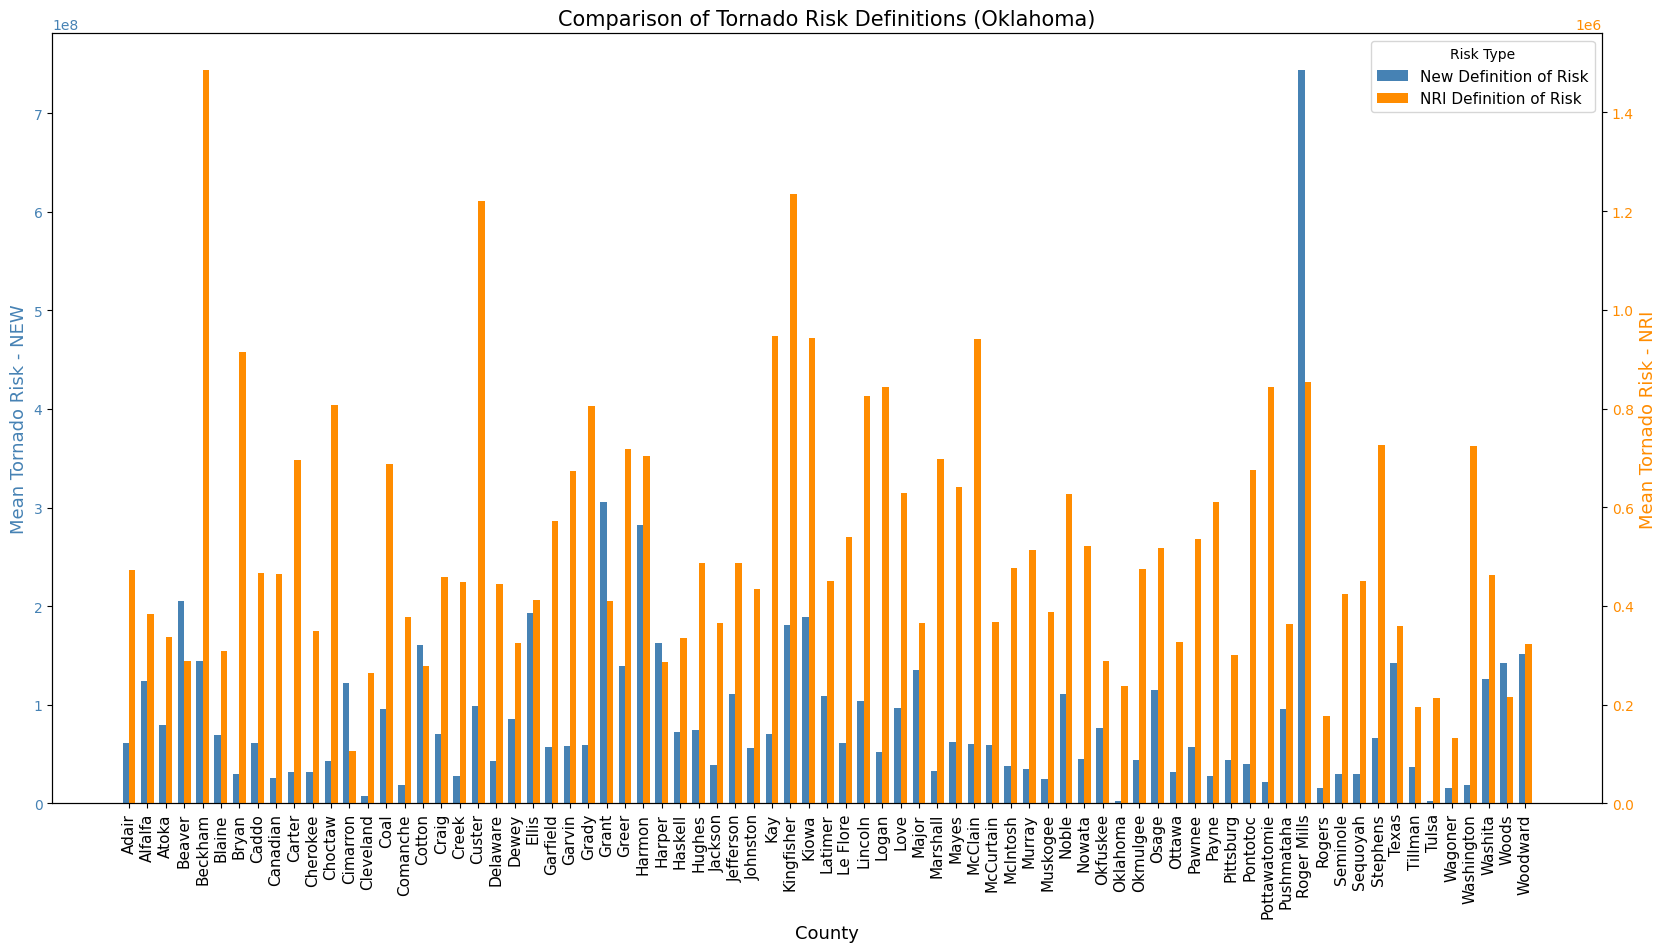

In [22]:
# Bar chart for Tornado Risk in Oklahoma VS NRI Risk

fig, ax1 = plt.subplots(figsize=(20, 10))

x = np.arange(len(Oklahoma_mean_data_NEW.index))
width = 0.35

# Plot tornado bars on the LEFT y-axis
bars1 = ax1.bar(x - width/2, Oklahoma_mean_data_NEW['mean_tornado'], width, label='mean_tornado', color='steelblue')
ax1.set_xlabel('County', fontsize=13)
ax1.set_ylabel('Mean Tornado Risk - NEW', color='steelblue', fontsize=13)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(Oklahoma_mean_data_NEW.index, rotation=90, fontsize=11)  # <-- use .index here too

# Create secondary y-axis for heat wave bars on the RIGHT
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, Oklahoma_mean_data_NRI['mean_tornado'], width, label='mean_heat', color='darkorange')
ax2.set_ylabel('Mean Tornado Risk - NRI', color='darkorange', fontsize=13)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Combined legend
ax1.legend([bars1, bars2], ['New Definition of Risk', 'NRI Definition of Risk'], title='Risk Type', fontsize=11)

plt.title('Comparison of Tornado Risk Definitions (Oklahoma)', fontsize=15)

plt.savefig("Comparison of Tornado Risk Definitions (Oklahoma).png")


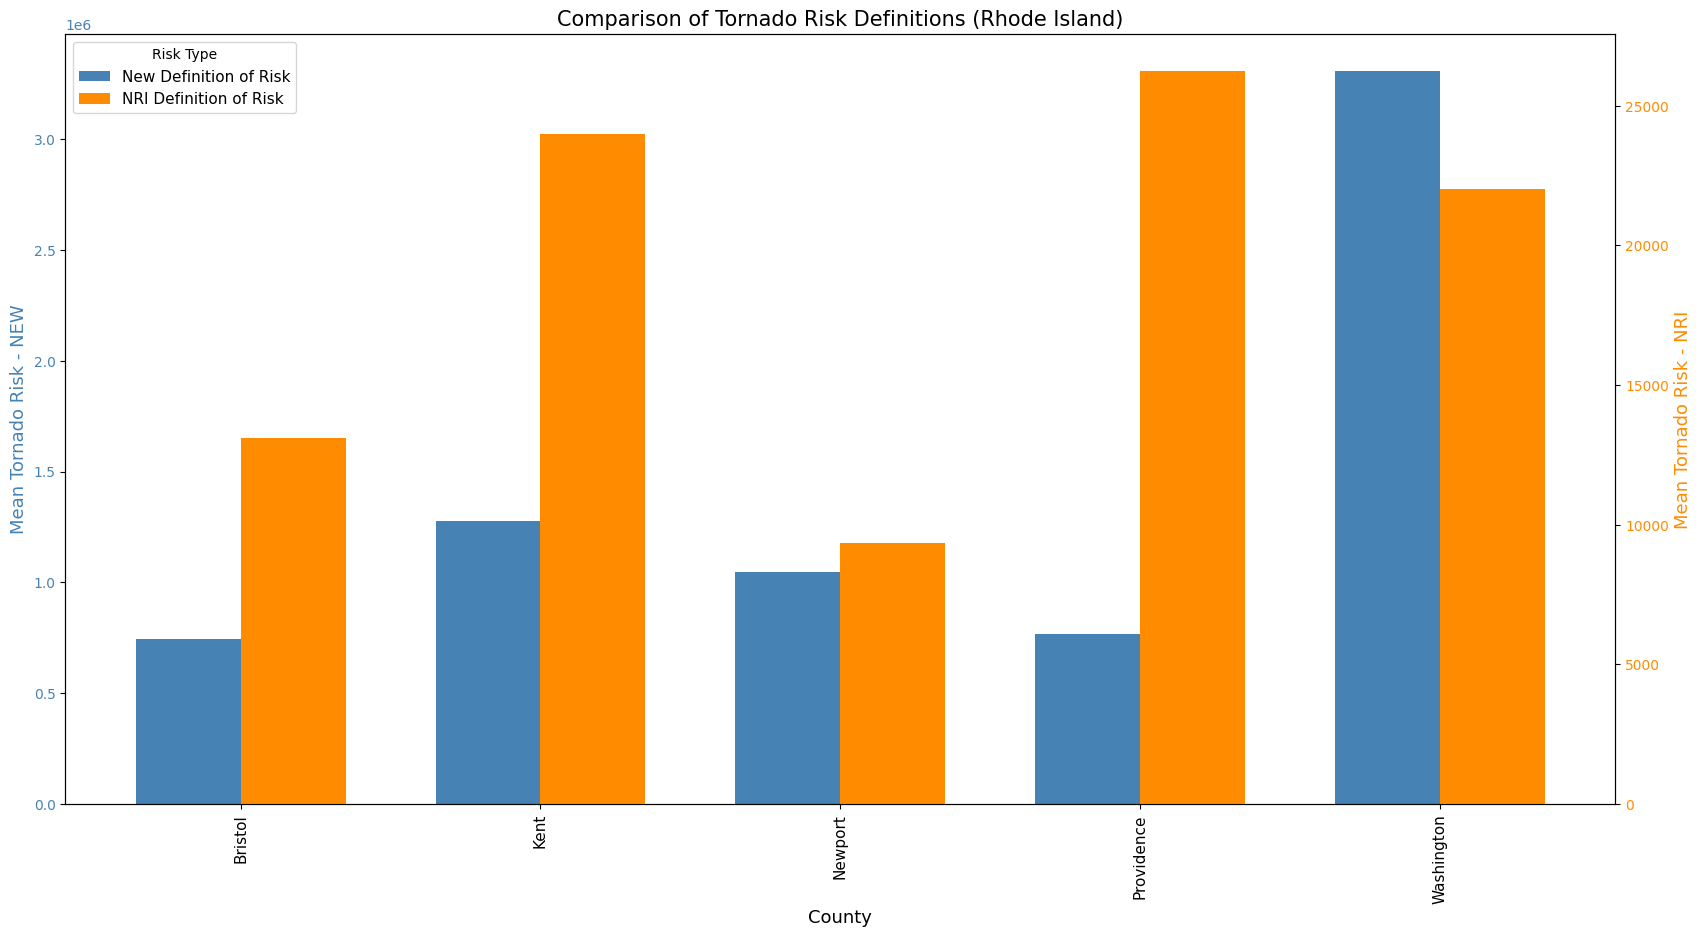

In [23]:
# Bar chart for Tornado Risk in Rhode Island VS NRI Risk

fig, ax1 = plt.subplots(figsize=(20, 10))

x = np.arange(len(RhodeIsland_mean_data_NEW.index))
width = 0.35

# Plot tornado bars on the LEFT y-axis
bars1 = ax1.bar(x - width/2, RhodeIsland_mean_data_NEW['mean_tornado'], width, label='mean_tornado', color='steelblue')
ax1.set_xlabel('County', fontsize=13)
ax1.set_ylabel('Mean Tornado Risk - NEW', color='steelblue', fontsize=13)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(RhodeIsland_mean_data_NEW.index, rotation=90, fontsize=11)  # <-- use .index here too

# Create secondary y-axis for heat wave bars on the RIGHT
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, RhodeIsland_mean_data_NRI['mean_tornado'], width, label='mean_heat', color='darkorange')
ax2.set_ylabel('Mean Tornado Risk - NRI', color='darkorange', fontsize=13)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Combined legend
ax1.legend([bars1, bars2], ['New Definition of Risk', 'NRI Definition of Risk'], title='Risk Type', fontsize=11)

plt.title('Comparison of Tornado Risk Definitions (Rhode Island)', fontsize=15)

plt.savefig("Comparison of Tornado Risk Definitions (Rhode Island).png")


## Geopandas Chloropleth Maps
These maps show visualize the risk value on a spatial map of each state. They are helpful in analysis becuase the maps generated for the NRI risk definition and the NEW definition can be compared for each state to see what is similar and what is different. 

In [16]:
# Checking the Projection and Setting it

shape_clean = shape.set_crs(epsg = 4326, inplace = True, allow_override = True) 

# Filter the shape data for Oklahoma 

ok_map = 'Oklahoma' 
ok_map = shape_clean[shape_clean['STATE'] == 'Oklahoma']

# Filter the shape data for Rhode Island 

ri_map = 'Rhode Island' 
ri_map = shape_clean[shape_clean['STATE'] == 'Rhode Island']


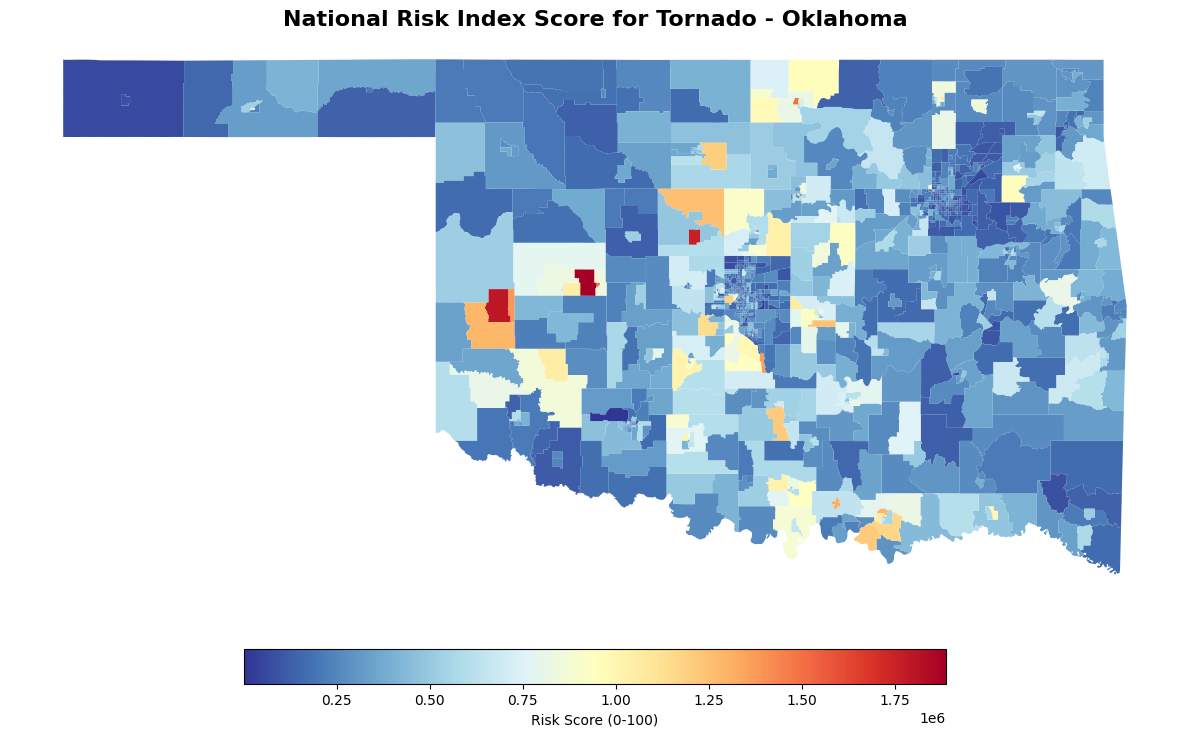

In [24]:
# Create the NRI RISK MAP for Oklahoma

fig,ax = plt.subplots(1,1, figsize = (12,10))

ok_map.plot(
    column = "TRND_RISKV",
    cmap = 'RdYlBu_r',
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True, 
    legend_kwds = {'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad':0.05},
    missing_kwds = {'color': 'lightgrey', 'label' : 'No Data'},
)

ax.set_title('National Risk Index Score for Tornado - Oklahoma', fontsize = 16, fontweight = 'bold')
ax.set_axis_off() 
plt.tight_layout()

plt.savefig("Chloropleth - National Risk Index Score for Tornado (Oklahoma).png")

plt.show()


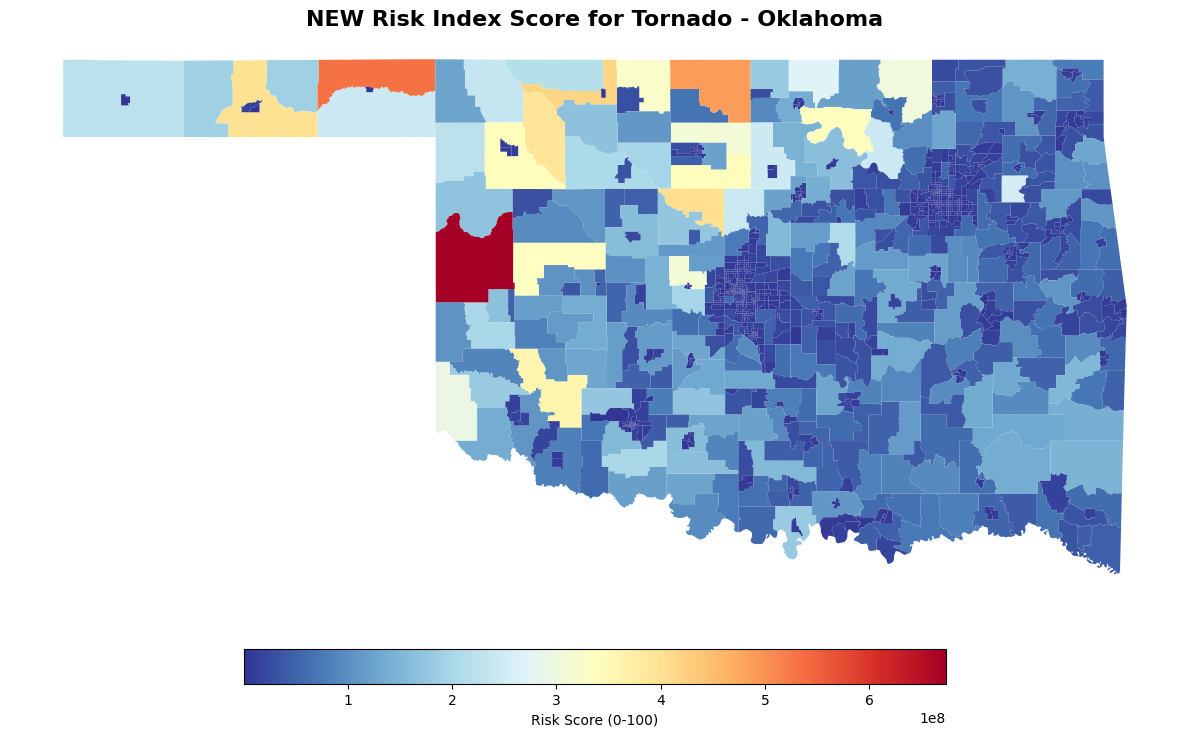

In [26]:
# Create the NEW RISK MAP for Oklahoma

fig,ax = plt.subplots(1,1, figsize = (12,10))

ok_map.plot(
    column = "tornado_building_risk",
    cmap = 'RdYlBu_r',
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True, 
    legend_kwds = {'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad':0.05},
    missing_kwds = {'color': 'lightgrey', 'label' : 'No Data'},
)

ax.set_title('NEW Risk Index Score for Tornado - Oklahoma', fontsize = 16, fontweight = 'bold')
ax.set_axis_off() 
plt.tight_layout()

plt.savefig("Chloropleth - NEW Risk Index Score for Tornado (Oklahoma).png")

plt.show()


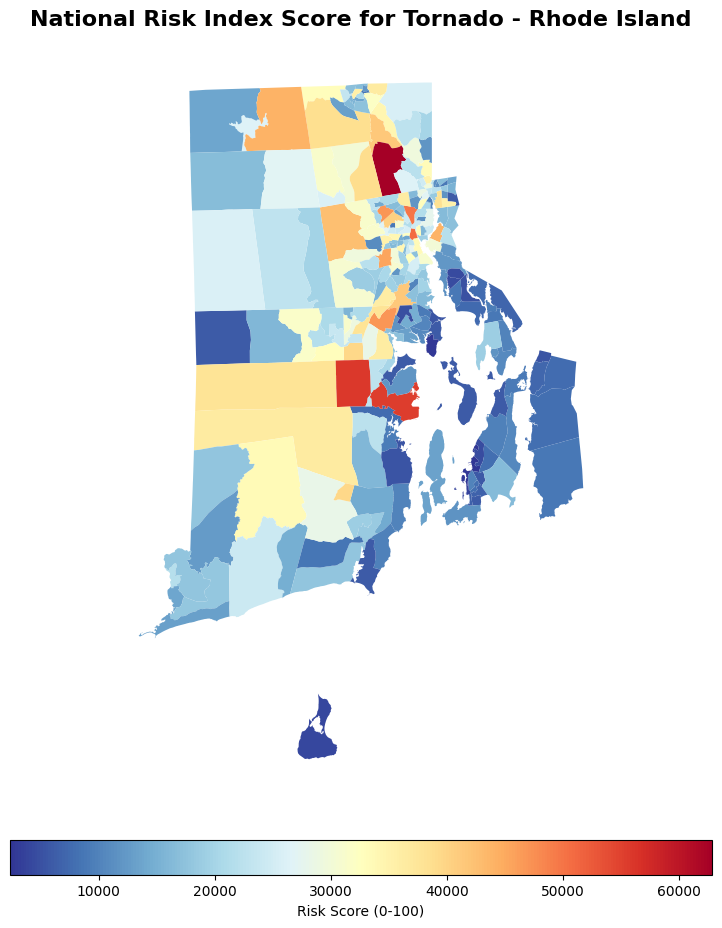

In [25]:
# Create the NRI RISK MAP for Rhode Island

fig,ax = plt.subplots(1,1, figsize = (12,10))

ri_map.plot(
    column = "TRND_RISKV",
    cmap = 'RdYlBu_r',
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True, 
    legend_kwds = {'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad':0.05},
    missing_kwds = {'color': 'lightgrey', 'label' : 'No Data'},
)

ax.set_title('National Risk Index Score for Tornado - Rhode Island', fontsize = 16, fontweight = 'bold')
ax.set_axis_off() 
plt.tight_layout()

plt.savefig("Chloropleth - National Risk Index Score for Tornado (Rhode Island).png")

plt.show()


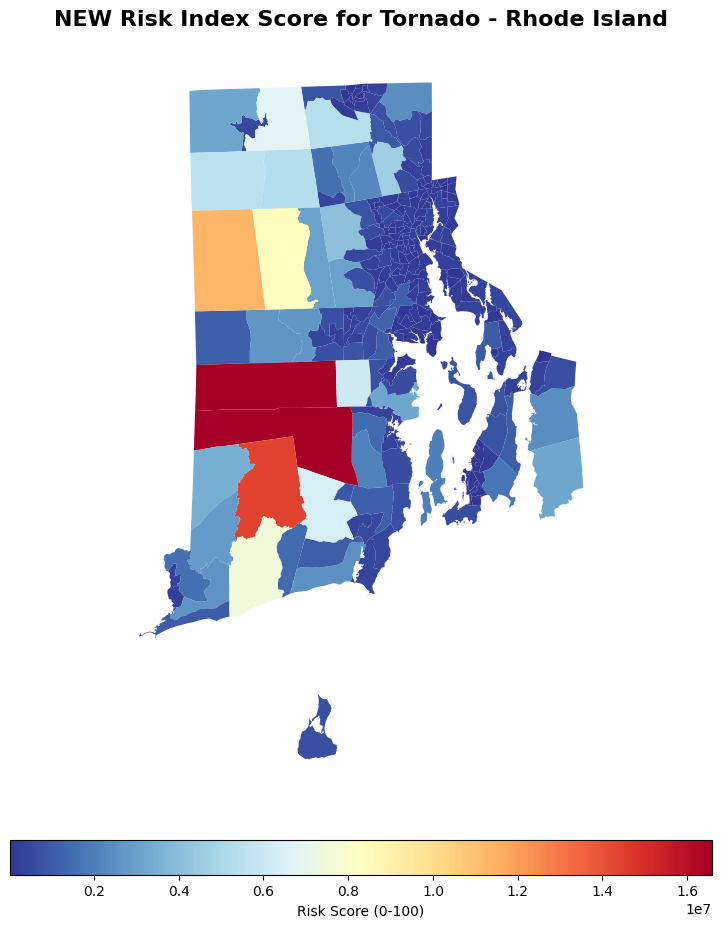

In [27]:
# Create the NEW RISK MAP for Rhode Island

fig,ax = plt.subplots(1,1, figsize = (12,10))

ri_map.plot(
    column = "tornado_building_risk",
    cmap = 'RdYlBu_r',
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True, 
    legend_kwds = {'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad':0.05},
    missing_kwds = {'color': 'lightgrey', 'label' : 'No Data'},
)

ax.set_title('NEW Risk Index Score for Tornado - Rhode Island', fontsize = 16, fontweight = 'bold')
ax.set_axis_off() 
plt.tight_layout()

plt.savefig("Chloropleth - NEW Risk Index Score for Tornado (Rhode Island).png")

plt.show()
